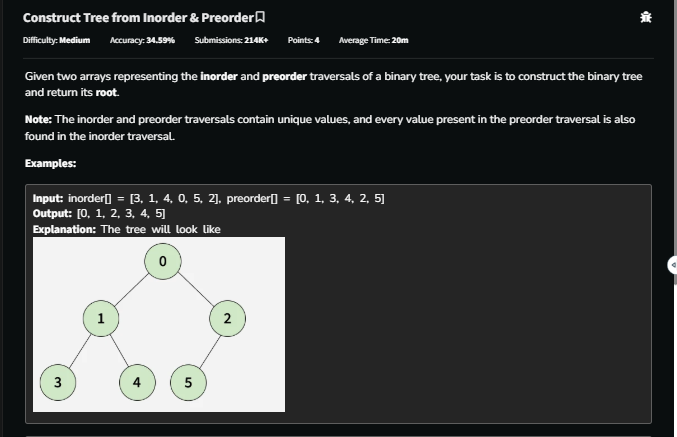
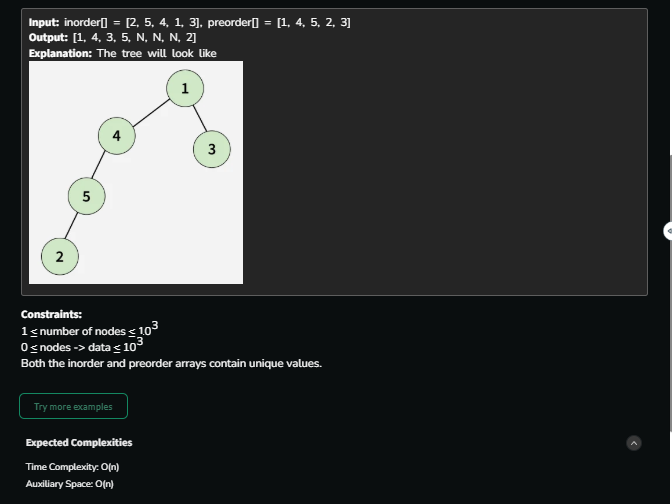

In [ ]:

# Definition for Node
class Node:
    def __init__(self, val):
        self.data = val
        self.right = None
        self.left = None

class Solution:
    def __init__(self):
        self.pre_index = 0
        
    def buildTree(self, inorder, preorder):
        # Reset index for multiple test cases if needed
        self.pre_index = 0
        n = len(preorder)
        return self.construct(inorder, 0, n - 1, preorder)
        
    def construct(self, inorder, i, j, preorder):
        # Base case
        if i > j:
            return None
            
        # Create root node from current preorder element
        root = Node(preorder[self.pre_index])
        self.pre_index += 1
        
        # Search for root index in inorder (O(N) operation)
        idx = self.searchInorder(inorder, root.data, i, j)
        
        # Recursively build left and right subtrees
        root.left = self.construct(inorder, i, idx - 1, preorder)
        root.right = self.construct(inorder, idx + 1, j, preorder)
        
        return root
        
    def searchInorder(self, inorder, data, i, j):
        # Linear search only within the current range [i, j]
        for k in range(i, j + 1):
            if inorder[k] == data:
                return k
        return -1   
        

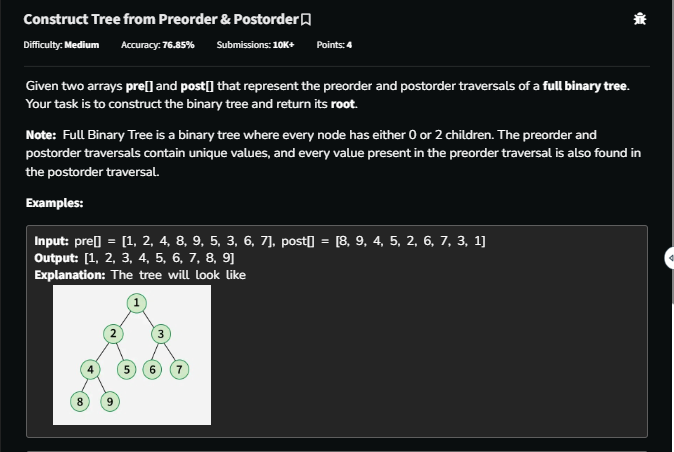
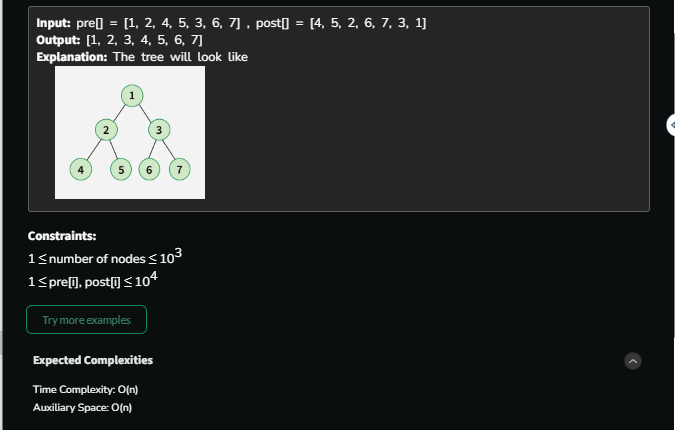

In [ ]:
'''
class Node:
    def __init__(self, val):
        self.data = val
        self.right = None
        self.left = None

'''


class Solution:
    def __init__(self):
        self.index = 0
    def constructTree(self, pre, post):
        # code here
        self.index = 0
        n = len(pre)
        return self.construct(pre, 0, n - 1, post)
        
    def construct(self, pre, i, j, post):
        
        if i > j:
            return -1
            
        root = Node(pre[self.index])
        self.index += 1
        
        if i == j:
            return root
        # here we are not searching for root.data but for the node at the left of the root in D-L-R
        ind = self.searchPost(pre[self.index], i, j, post)
            
        root.left = self.construct(pre, i, ind, post)
        root.right = self.construct(pre, ind + 1, j - 1, post)
        
        return root
        
    def searchPost(self, left_ele, i, j, post):
        
        for k in range(i, j):
            if post[k] == left_ele:
                return k
        return -1
        
        

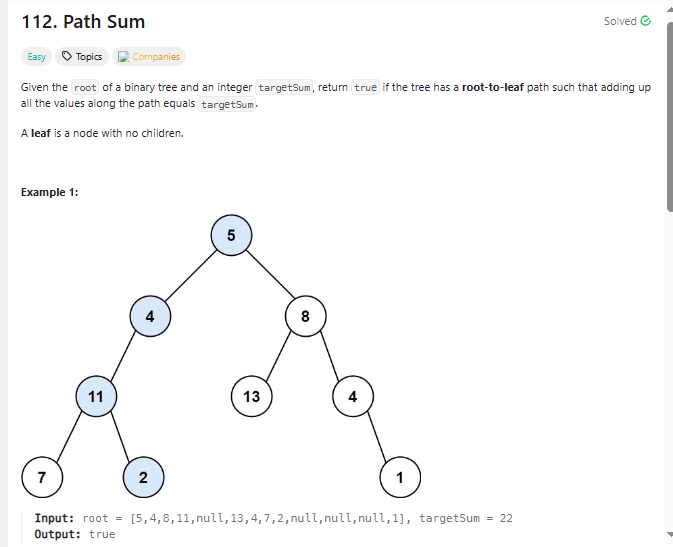
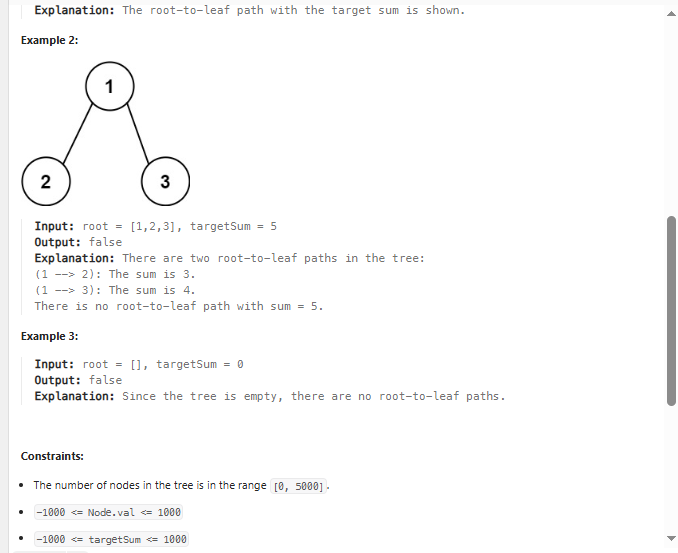

In [ ]:
# Definition for a binary tree node.
# class TreeNode(object):
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution(object):
    def hasPathSum(self, root, targetSum):
        """
        :type root: Optional[TreeNode]
        :type targetSum: int
        :rtype: bool
        """

        if root is None:
            return False
        
        if root.left == None and root.right == None:
            targetSum -= root.val
            if targetSum == 0:
                return True 
            else:
                return False
        left_sum = self.hasPathSum(root.left, targetSum - root.val)
        right_sum = self.hasPathSum(root.right, targetSum - root.val)

        return left_sum or right_sum
        

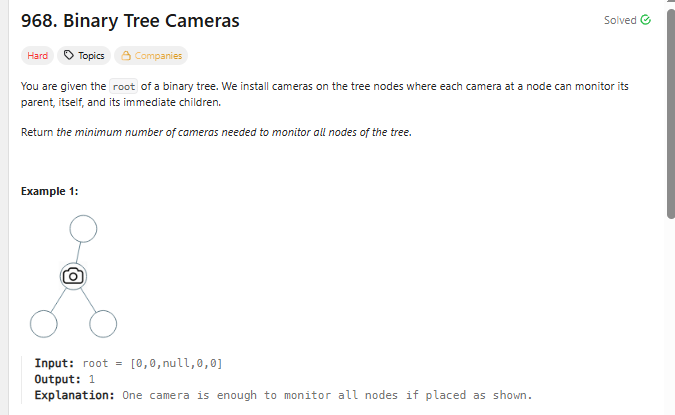
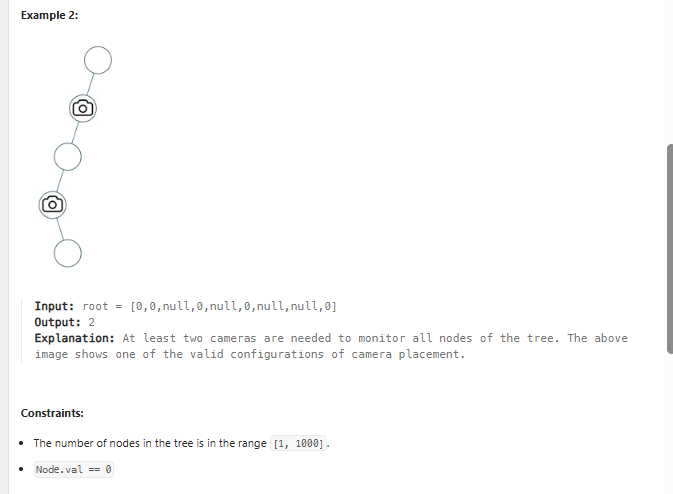

In [ ]:
# Definition for a binary tree node.
# class TreeNode(object):
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution(object):
    def __init__(self):
        self.count = 0
        
    def minCameraCover(self, root):
        """
        :type root: Optional[TreeNode]
        :rtype: int
        """
        self.count = 0
        # handling the case of sigle root
        if self.camcount(root) == -1:
            self.count += 1
        return self.count

    def camcount(self, root):
        if root is None:
            return 0
        
        left = self.camcount(root.left)
        right = self.camcount(root.right)

        if left == -1 or right == -1:
            self.count += 1
            return 1

        if left == 1 or right == 1:
            return 0

        return -1

        # return self.count

Home Work

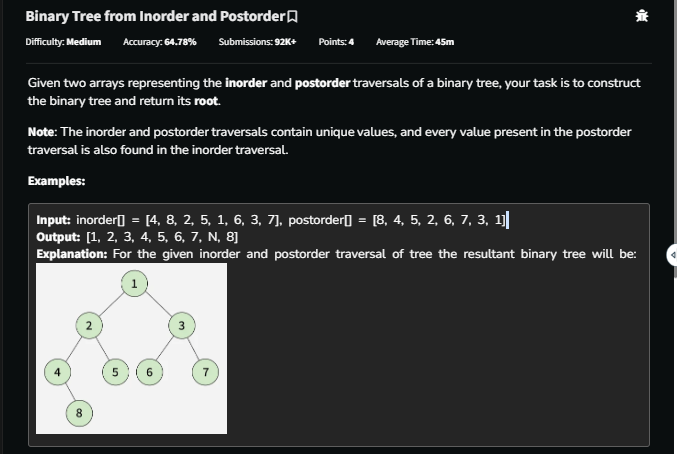
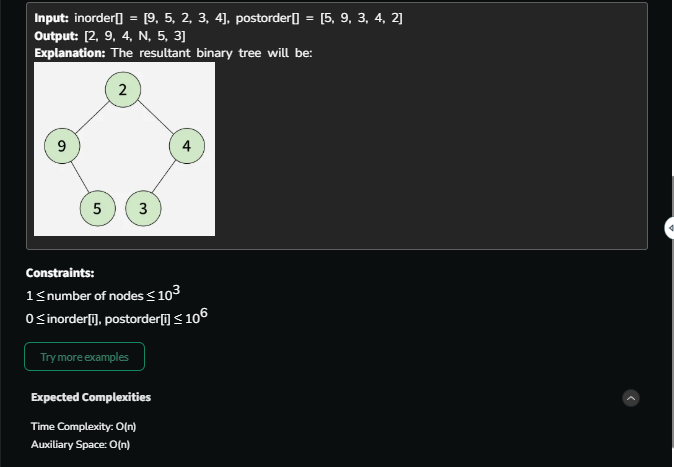

In [ ]:
'''
class Node:
    def __init__(self, x):
        self.data = x
        self.left = None
        self.right = None
'''        


class Solution:
    def __init__(self):
        self.index = 0
    def buildTree(self, inorder, postorder):
        #code here
        
        n = len(postorder)
        self.index = n - 1
        return self.construct(inorder, 0, n - 1, postorder)
    
    def construct(self, inorder, i, j, postorder):
        
        if i > j:
            return None
        
        root = Node(postorder[self.index])
        self.index -= 1
        
        if i == j:
            return root
            
        ind = self.searchInorder(root.data, i, j, inorder)
            
        root.right = self.construct(inorder, ind + 1, j, postorder)
        root.left = self.construct(inorder, i, ind - 1, postorder)
        
        return root
        
    def searchInorder(self, right, i, j, inorder):
        
        for k in range(i, j + 1):
            if inorder[k] == right:
                return k
        return -1

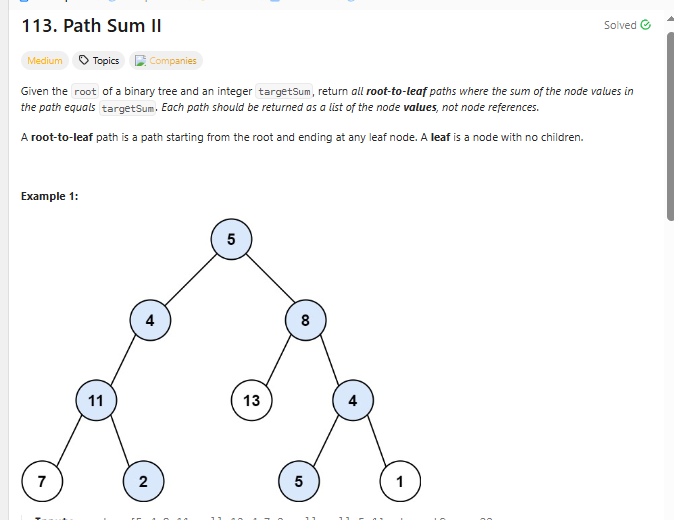
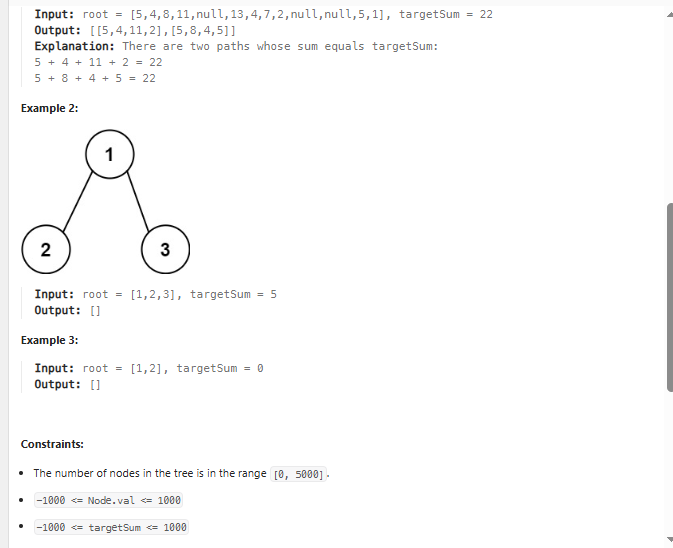

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def pathSum(self, root: Optional[TreeNode], targetSum: int) -> List[List[int]]:
        """
        :type root: Optional[TreeNode]
        :type targetSum: int
        :rtype: List[List[int]]
        """
        path = []
        result = []

        def dfs(root, target):

            if not root:
                return 

            path.append(root.val)
            remaining = target - root.val

            if not root.left and not root.right and remaining == 0:
                result.append(path[:])

            dfs(root.left, remaining)
            dfs(root.right, remaining)

            path.pop()

        dfs(root, targetSum)
        return result
        